In [102]:
# Testing Single Sided Ranging

In [103]:
import json
import numpy as np
import matplotlib.pyplot as plt

TRIALNAME = "uwb_ssr_test1"
IN_PATH = f"/home/antond2/Desktop/Research/MultiXR-Post/2/collect/{TRIALNAME}_nuc2_raw/uwb_raw.json"

#IN_PATH = "uwb_raw.json"

GT = 0.5 #m
UUS_TO_DWT_TIME = 65536
SPEED_OF_LIGHT = 299702547 # m/s
DWT_TIME_UNITS = 1.0 / 499.2e6 / 128.0 #!< = 15.65e-12 s

# All timestamps are in dtu
def to_s(dtu_ts): return dtu_ts * DWT_TIME_UNITS
    
all = json.load(open(IN_PATH, 'r'))


In [104]:
# Validating + cleaning reported timestamps

ranges = [] # Just the json objects
reported_ranges = []
calculated_ranges = []
avg_hold_time_src = []
avg_hold_time_dst = []
overflow_errors = 0

for i, r in enumerate(all):
    if r["type"] == "uwb":
        ascending_src = r["poll_src_tx"] < r["resp_src_rx"] < r["final_src_tx"]
        ascending_dst = r["poll_dst_rx"] < r["resp_dst_tx"] < r["final_dst_rx"]

        # To ensure that all equations are in a consistent frame
        # i.e. some equations don't suggest opposite skew drift, this happens whenever timestamps overflow at different times
        # between src and dst
        dst_greater_than_src = to_s(r["poll_src_tx"]) + 5e-3 < to_s(r["poll_dst_rx"])

        if ascending_src and ascending_dst and dst_greater_than_src:
            ranges.append(r)
    
            poll_src_tx = to_s(r["poll_src_tx"])
            resp_src_rx   = to_s(r["resp_src_rx"])
            final_src_tx  = to_s(r["final_src_tx"])
            poll_dst_rx   = to_s(r["poll_dst_rx"])
            resp_dst_tx   = to_s(r["resp_dst_tx"])
            final_dst_rx  = to_s(r["final_dst_rx"])
    
            avg_hold_time_src.append(final_src_tx - resp_src_rx)
            avg_hold_time_dst.append(resp_dst_tx - poll_dst_rx)

            # Note timestamps already in s so tof is in s
            roundB = (final_dst_rx - resp_dst_tx)
            replyB = (resp_dst_tx - poll_dst_rx)
            roundA = (resp_src_rx - poll_src_tx)
            replyA = (final_src_tx - resp_src_rx)
            tof_s = ((roundA * roundB - replyA * replyB) /
                        (roundA + roundB + replyA + replyB))
            calculated_ranges.append(tof_s * SPEED_OF_LIGHT )
            reported_ranges.append(r["range"])
        else:
            overflow_errors +=1


print(f"Validating ROS reported timestamps")
print(f"{overflow_errors} overflows / {len(all)} ranges")

reported_ranges, calculated_ranges = (np.array(reported_ranges), np.array(calculated_ranges))

print(f" Range reported vs range computed with timestamps should have same error ")
avg_reported_range_err = np.mean(np.abs(reported_ranges - GT))
print(f"{avg_reported_range_err=}")
avg_calculated_range_err = np.mean(np.abs(calculated_ranges - GT))
print(f"{avg_calculated_range_err=}")

# Ok this being correct kind of conflicts with the notion that the timestamp data is off.
# But at the same time then why is my dstwr formula giving the wrong answer?
print(f" Message hold time at initiator, should be ~2.0ms = { np.mean(np.array(avg_hold_time_src))=}")
print(f" Message hold time at responder, should be ~1.5ms = { np.mean(np.array(avg_hold_time_dst))=}")


import matplotlib.pyplot as plt

def timeline_range(r):

    poll_src_tx  = to_s(r["poll_src_tx"])
    resp_src_rx  = to_s(r["resp_src_rx"])
    final_src_tx = to_s(r["final_src_tx"])

    poll_dst_rx  = to_s(r["poll_dst_rx"])
    resp_dst_tx  = to_s(r["resp_dst_tx"])
    final_dst_rx = to_s(r["final_dst_rx"])

    fig, ax = plt.subplots(figsize=(12, 4))

    # Timeline y locations
    y_src = 1
    y_dst = 0

    # Draw clock timelines
    ax.hlines(y_src, poll_src_tx, final_src_tx, linewidth=2)
    ax.hlines(y_dst, poll_dst_rx, final_dst_rx, linewidth=2)

    # Plot events
    ax.plot(poll_src_tx,  y_src, 'o')
    ax.plot(resp_src_rx,  y_src, 'o')
    ax.plot(final_src_tx, y_src, 'o')

    ax.plot(poll_dst_rx,  y_dst, 'o')
    ax.plot(resp_dst_tx,  y_dst, 'o')
    ax.plot(final_dst_rx, y_dst, 'o')

    # Message arrows
    ax.annotate(
        "",
        xy=(poll_dst_rx, y_dst),
        xytext=(poll_src_tx, y_src),
        arrowprops=dict(arrowstyle="->")
    )

    ax.annotate(
        "",
        xy=(resp_src_rx, y_src),
        xytext=(resp_dst_tx, y_dst),
        arrowprops=dict(arrowstyle="->")
    )

    ax.annotate(
        "",
        xy=(final_dst_rx, y_dst),
        xytext=(final_src_tx, y_src),
        arrowprops=dict(arrowstyle="->")
    )

    # Labels
    ax.text(poll_src_tx,  y_src + 0.05, "poll_src_tx")
    ax.text(resp_src_rx,  y_src + 0.05, "resp_src_rx")
    ax.text(final_src_tx, y_src + 0.05, "final_src_tx")

    ax.text(poll_dst_rx,  y_dst - 0.1, "poll_dst_rx")
    ax.text(resp_dst_tx,  y_dst - 0.1, "resp_dst_tx")
    ax.text(final_dst_rx, y_dst - 0.1, "final_dst_rx")

    # Axis formatting
    ax.set_yticks([y_dst, y_src])
    ax.set_yticklabels(["Destination Clock", "Source Clock"])

    ax.set_xlabel("Time (s)")
    ax.set_title("UWB Range Exchange Timeline")

    ax.grid(True)

    plt.tight_layout()
    plt.show()

def timeline_poll_src(r, poll_src_rx):

    poll_src_tx  = to_s(r["poll_src_tx"])
    resp_src_rx  = to_s(r["resp_src_rx"])
    final_src_tx = to_s(r["final_src_tx"])

    fig, ax = plt.subplots(figsize=(12, 4))

    # Two separate "source clock" timelines
    y_main = 1
    y_proj = 0

    # Main source timeline
    ax.hlines(y_main, poll_src_tx, final_src_tx, linewidth=2)

    # Projected/source-aligned timeline
    ax.hlines(
        y_proj,
        min(poll_src_tx, poll_src_rx),
        max(final_src_tx, poll_src_rx),
        linewidth=2
    )

    # Main timestamps
    ax.plot(poll_src_tx,  y_main, 'o')
    ax.plot(resp_src_rx,  y_main, 'o')
    ax.plot(final_src_tx, y_main, 'o')

    # Projected timestamp
    ax.plot(poll_src_rx, y_proj, 'o')

    # Labels
    ax.text(poll_src_tx,  y_main + 0.05, "poll_src_tx")
    ax.text(resp_src_rx,  y_main + 0.05, "resp_src_rx")
    ax.text(final_src_tx, y_main + 0.05, "final_src_tx")

    ax.text(poll_src_rx, y_proj - 0.12, "poll_src_rx")

    # Optional alignment line
    ax.vlines(
        poll_src_rx,
        y_proj,
        y_main,
        linestyles='dashed'
    )

    # Formatting
    ax.set_yticks([y_proj, y_main])
    ax.set_yticklabels([
        "Source Clock (projected)",
        "Source Clock"
    ])

    ax.set_xlabel("Time (s)")
    ax.set_title("Projected Poll RX Timestamp onto Source Clock")

    ax.grid(True)

    plt.tight_layout()
    plt.show()
print(f" Spot checking ranges: ")
for idx in [0, 50, 130, 180, 220]:
    print(f"\n{'='*20} RANGE {idx} {'='*20}")
    print(json.dumps(ranges[idx], indent=4))
    # timeline_range(ranges[idx])
        

Validating ROS reported timestamps
150 overflows / 392 ranges
 Range reported vs range computed with timestamps should have same error 
avg_reported_range_err=np.float64(0.027049587162072994)
avg_calculated_range_err=np.float64(0.02687070595021282)
 Message hold time at initiator, should be ~2.0ms =  np.mean(np.array(avg_hold_time_src))=np.float64(0.002051535224114265)
 Message hold time at responder, should be ~1.5ms =  np.mean(np.array(avg_hold_time_dst))=np.float64(0.0015387146949323463)
 Spot checking ranges: 

==================== RANGE 0 ====================
{
    "t": 1778006900.7079797,
    "type": "uwb",
    "id": 1,
    "range": 0.5018680095672607,
    "exchange": 781,
    "maxnoise": 1260,
    "firstpathamp1": 6998,
    "firstpathamp2": 8034,
    "firstpathamp3": 6811,
    "stdnoise": 48,
    "maxgrowthcir": 2062,
    "rxpreamcount": 116,
    "firstpath": 47652,
    "poll_src_tx": 2024502836,
    "poll_dst_rx": 3504322248,
    "resp_dst_tx": 3602642484,
    "resp_src_rx": 21

In [110]:
### Compute SSR results:

def evaluate_ssr(D_dst_src, S_dst_src, tof_ = GT / SPEED_OF_LIGHT):

    ssr_ranges = []

    tofs = []
    poll_src_tx_ = []
    poll_dst_rx_ = []
    base_ranges = []

    
    for i, r in enumerate(ranges):
    
        # Now we treat each double sided two way range as 
        # a single sided range by just looking at the poll message
        poll_src_tx = to_s(r["poll_src_tx"])
        poll_dst_rx   = to_s(r["poll_dst_rx"])
    
        poll_src_rx = (1 + D_dst_src)*poll_dst_rx + S_dst_src
    
        tof_est = poll_src_rx - poll_src_tx
        tofs.append(tof_est)
        # print(f"{tof_est=}")
        # if (tof_est < 0):
        #     print(f"{poll_src_rx=} - {poll_src_tx=}")
        #     print("WTF")

        base_ranges.append(SPEED_OF_LIGHT * (poll_dst_rx - poll_src_tx))
        
        poll_src_tx_.append(poll_src_tx)
        poll_dst_rx_.append(poll_dst_rx)
        
        range_est = SPEED_OF_LIGHT * tof_est

        # if tof_est < 0:
        #     print("Negative tof ", i)

        # if i%50 == 0:
        #     timeline_range(r)
        #     timeline_poll_src(r, poll_src_rx)
        
        ssr_ranges.append(range_est)
        
    plt.plot(tofs)
    plt.title("ToF Estimates (s)")
    plt.show()
    
    return eval_error(ssr_ranges, reported_ranges, base_ranges)

def eval_error(ssr_ranges, reported_ranges, base_ranges=None):
    reported_ranges = np.array(reported_ranges)
    ssr_ranges = np.array(ssr_ranges)

    dstwr_err = np.abs(reported_ranges - GT)
    avg_dstwr_err = np.mean(dstwr_err)
    std_dstwr_err = np.std(dstwr_err)

    ssr_err = np.abs(ssr_ranges - GT)

    plt.plot(ssr_err)
    plt.title("Single Side Ranging Error (m)")
    plt.show()

    if base_ranges is not None:
        base_ranges = np.array(base_ranges)
        base_err = np.abs(base_ranges - GT)
        plt.plot(base_err)
        plt.title("Base Single Side Ranging Error (m)")
        plt.show()
    
    avg_ssr_err = np.mean(ssr_err)
    std_ssr_err = np.std(ssr_err)

    print(f"{avg_dstwr_err=}\n {std_dstwr_err=}")
    print(f"{avg_ssr_err=}\n {std_ssr_err=}")
    
    return avg_dstwr_err, avg_ssr_err

Analyzing estimated D, S
drift mean: -4.301245238535482e-07
drift stdev: 1.1629568359835692e-07
skew mean: -0.02318066144854771
skew stdev: 1.4742922078378058e-05
Using D, S for SSR


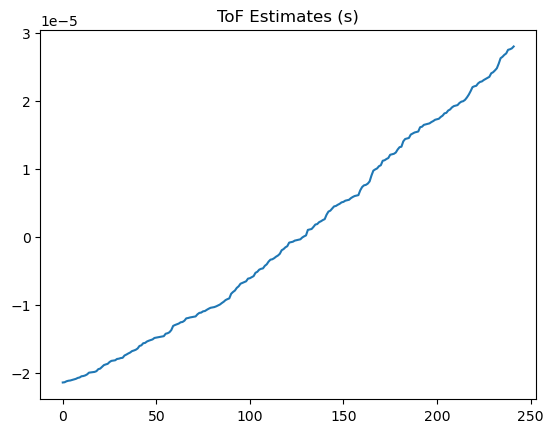

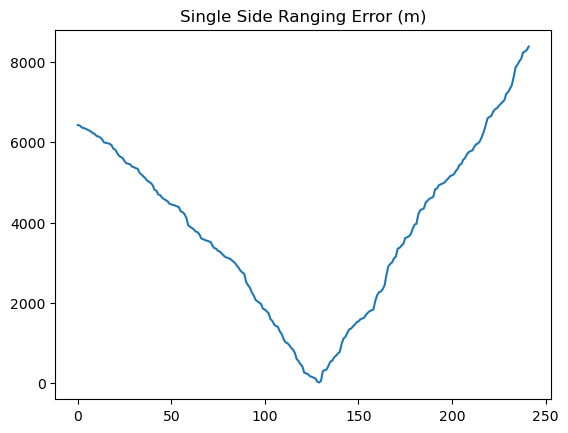

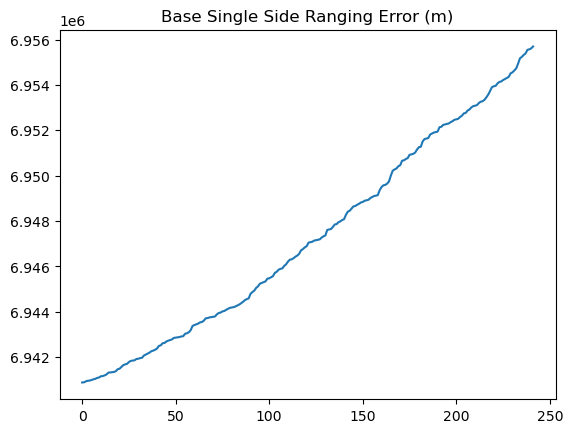

avg_dstwr_err=np.float64(0.027049587162072994)
 std_dstwr_err=np.float64(0.021665392285239574)
avg_ssr_err=np.float64(3862.3699626978246)
 std_ssr_err=np.float64(2148.528437537648)


In [117]:
### Using 3 equations and least squares

def three_eq_ls(tof_=GT / SPEED_OF_LIGHT):

    drift_dst_src = [] # drift from destination to source
    skew_dst_src = []
    
    for r in ranges:
        
        poll_src_tx = to_s(r["poll_src_tx"])
        resp_src_rx   = to_s(r["resp_src_rx"])
        final_src_tx  = to_s(r["final_src_tx"])
        poll_dst_rx   = to_s(r["poll_dst_rx"])
        resp_dst_tx   = to_s(r["resp_dst_tx"])
        final_dst_rx  = to_s(r["final_dst_rx"])
        
        A = np.array(
                    [[ poll_dst_rx, 1],
                      [resp_dst_tx, 1],
                      [final_dst_rx, 1]]
                    )
        b = np.array([ poll_src_tx + tof_ - poll_dst_rx,
                     resp_src_rx - tof_ - resp_dst_tx,
                     final_src_tx + tof_ - final_dst_rx ])
        
        x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
        drift_dst_src.append(x[0])
        skew_dst_src.append(x[1])

    return np.array(drift_dst_src), np.array(skew_dst_src)

print(f"Analyzing estimated D, S")

drift_dst_src, skew_dst_src = three_eq_ls()

D_dst_src = np.mean(drift_dst_src)
S_dst_src = np.mean(skew_dst_src)

print("drift mean:", D_dst_src)
print("drift stdev:", np.std(drift_dst_src))

print("skew mean:", S_dst_src)
print("skew stdev:", np.std(skew_dst_src))

print(f"Using D, S for SSR")
dstwr_err, ssr_err = evaluate_ssr(D_dst_src, S_dst_src)


Analyzing estimated D, S
drift: 3.7488420644701035e-05
skew: -0.02318236138344528
Using D, S for SSR


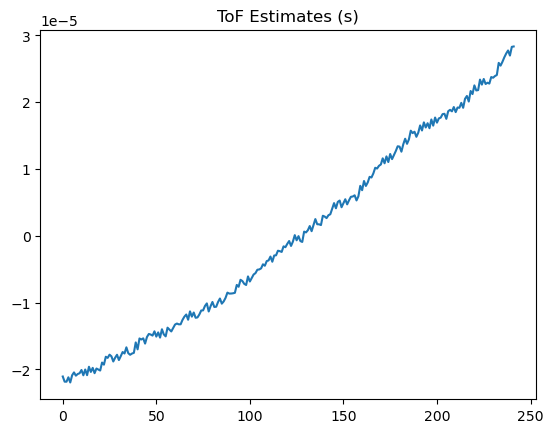

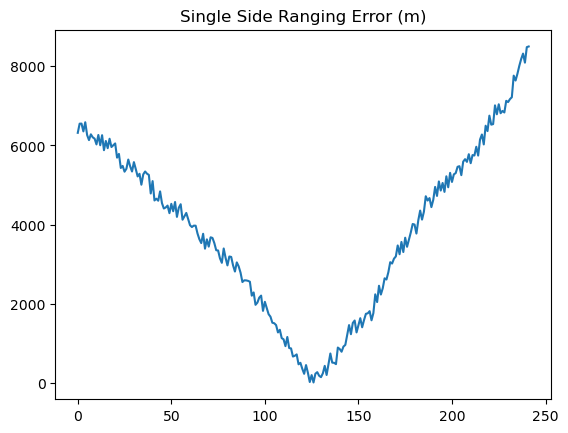

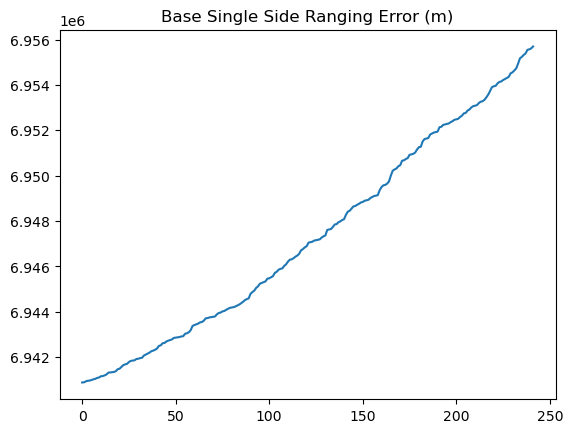

avg_dstwr_err=np.float64(0.027049587162072994)
 std_dstwr_err=np.float64(0.021665392285239574)
avg_ssr_err=np.float64(3864.02429113893)
 std_ssr_err=np.float64(2141.3139628363256)


In [114]:
### Using all equations (stacked) and least squares

def all_eq_ls(tof_=GT / SPEED_OF_LIGHT):

    A = []
    b = []

    for r in ranges:
        
        poll_src_tx  = to_s(r["poll_src_tx"])
        resp_src_rx  = to_s(r["resp_src_rx"])
        final_src_tx = to_s(r["final_src_tx"])
        poll_dst_rx  = to_s(r["poll_dst_rx"])
        resp_dst_tx  = to_s(r["resp_dst_tx"])
        final_dst_rx = to_s(r["final_dst_rx"])

        # stack all equations across all ranges
        A.append([poll_dst_rx, 1])
        A.append([resp_dst_tx, 1])
        A.append([final_dst_rx, 1])

        b.append(poll_src_tx + tof_ - poll_dst_rx)
        b.append(resp_src_rx - tof_ - resp_dst_tx)
        b.append(final_src_tx + tof_ - final_dst_rx)

    A = np.array(A)
    b = np.array(b)

    x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

    # single global estimate
    drift_dst_src = x[0]
    skew_dst_src  = x[1]

    return drift_dst_src, skew_dst_src


print(f"Analyzing estimated D, S")

D_dst_src, S_dst_src = all_eq_ls()

print("drift:", D_dst_src)
print("skew:", S_dst_src)

print(f"Using D, S for SSR")
dstwr_err, ssr_err = evaluate_ssr(D_dst_src, S_dst_src)


Analyzing estimated D, S
drift mean: -0.5574955988146757
drift std: 0.1609332131918543


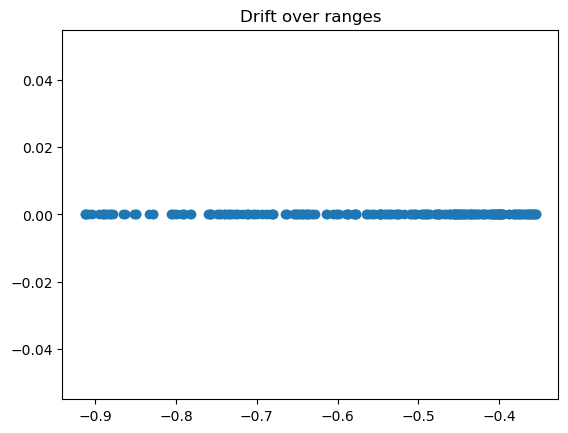

Using D, S for SSR


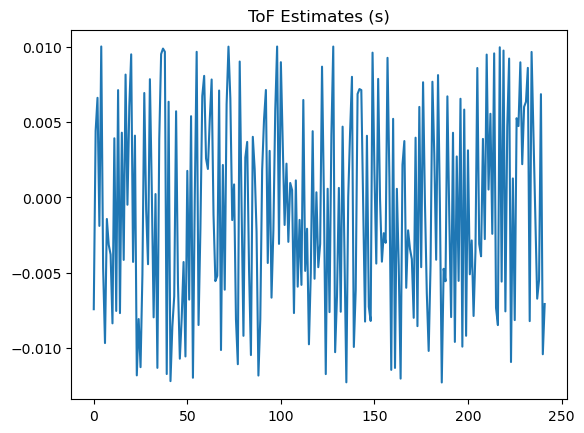

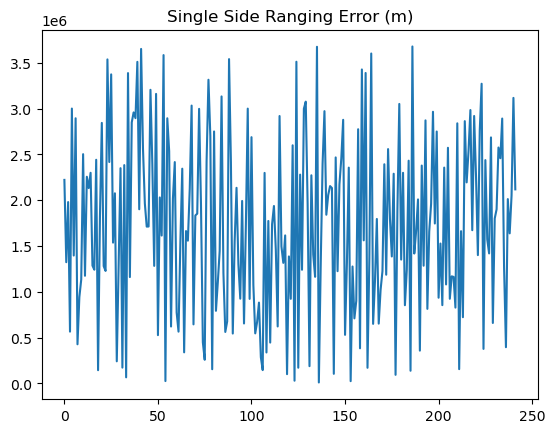

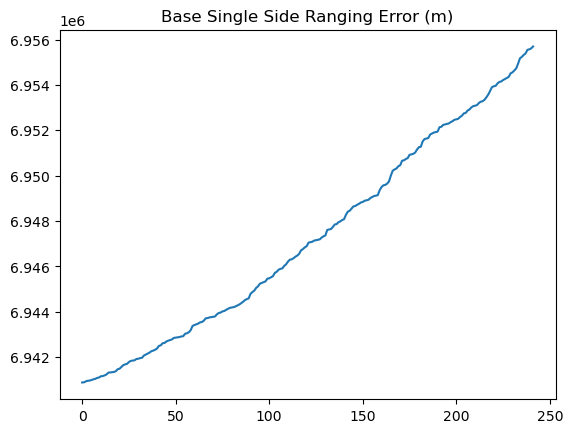

avg_dstwr_err=np.float64(0.027049587162072994)
 std_dstwr_err=np.float64(0.021665392285239574)
avg_ssr_err=np.float64(1739303.3001716926)
 std_ssr_err=np.float64(964193.3141911644)


In [83]:
### Using vector math with no skew

def vector(tof_=GT / SPEED_OF_LIGHT):

    drift_dst_src = [] # drift from destination to source
    skew_dst_src = []
    
    for r in ranges:
        
        poll_src_tx = to_s(r["poll_src_tx"])
        resp_src_rx   = to_s(r["resp_src_rx"])
        final_src_tx  = to_s(r["final_src_tx"])
        poll_dst_rx   = to_s(r["poll_dst_rx"])
        resp_dst_tx   = to_s(r["resp_dst_tx"])
        final_dst_rx  = to_s(r["final_dst_rx"])
        # report_src_rx = to_s(j["report_src_rx"])
        # report_dst_tx = to_s(j["report_dst_tx"])
        
        a = np.array(
                    [[ poll_dst_rx],
                      [resp_dst_tx],
                      [final_dst_rx]]
                    )
        b = np.array([ poll_src_tx + tof_ - poll_dst_rx,
                     resp_src_rx - tof_ - resp_dst_tx,
                     final_src_tx + tof_ - final_dst_rx ])

        x = a.T @ b / ((a.T @ a)[0])
        
        drift_dst_src.append(x[0])

    return np.array(drift_dst_src), 0

print(f"Analyzing estimated D, S")

drift_dst_src, _ = vector()

D_dst_src = np.mean(drift_dst_src)

print("drift mean:", D_dst_src)
print("drift std:", np.std(drift_dst_src))

plt.scatter(drift_dst_src,  np.zeros_like(drift_dst_src))
plt.title("Drift over ranges")

plt.show()

print(f"Using D, S for SSR")
dstwr_err, ssr_err = evaluate_ssr(D_dst_src, 0)


Analyzing estimated D, S
drift mean: -0.4830677534375427
drift std: 0
Using D, S for SSR


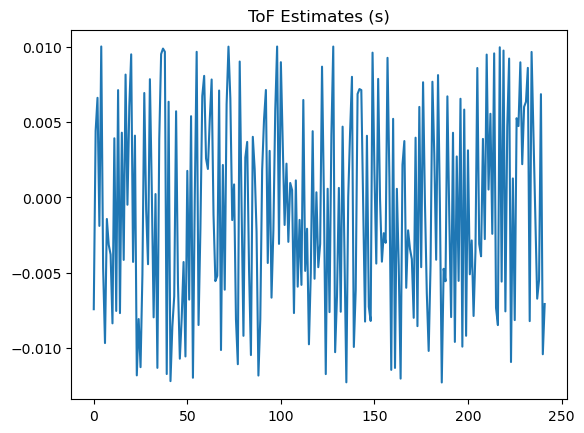

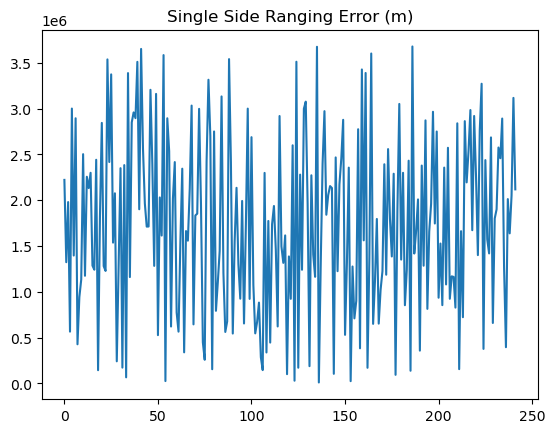

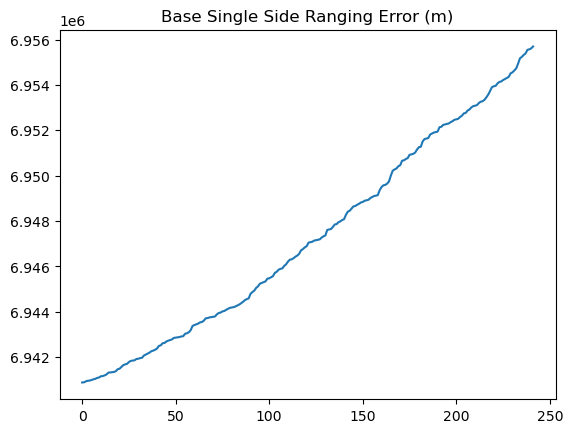

avg_dstwr_err=np.float64(0.027049587162072994)
 std_dstwr_err=np.float64(0.021665392285239574)
avg_ssr_err=np.float64(1739303.3001716926)
 std_ssr_err=np.float64(964193.3141911644)


In [82]:
### Using vector math with no skew and all equations


def vector_all(tof_=GT / SPEED_OF_LIGHT):

    drift_dst_src = [] # drift from destination to source
    skew_dst_src = []
    
    a, b = [], []
    
    for r in ranges:
        
        poll_src_tx = to_s(r["poll_src_tx"])
        resp_src_rx   = to_s(r["resp_src_rx"])
        final_src_tx  = to_s(r["final_src_tx"])
        poll_dst_rx   = to_s(r["poll_dst_rx"])
        resp_dst_tx   = to_s(r["resp_dst_tx"])
        final_dst_rx  = to_s(r["final_dst_rx"])
        # report_src_rx = to_s(j["report_src_rx"])
        # report_dst_tx = to_s(j["report_dst_tx"])
        
        a= a+ (
                    [ poll_dst_rx,
                      resp_dst_tx,
                      final_dst_rx]
                    )
        b =b +([ poll_src_tx + tof_ - poll_dst_rx,
                     resp_src_rx - tof_ - resp_dst_tx,
                     final_src_tx + tof_ - final_dst_rx ])

    return np.array(a), np.array(b)

print(f"Analyzing estimated D, S")

a,b = vector_all()

x = a.T @ b / ((a.T @ a))

print("drift mean:", x)
print("drift std:", 0)

print(f"Using D, S for SSR")
dstwr_err, ssr_err = evaluate_ssr(D_dst_src, 0)


Analyzing estimated D, S
drift mean: -0.5574955988146757
drift std: 0.1609332131918543
Using D, S for SSR


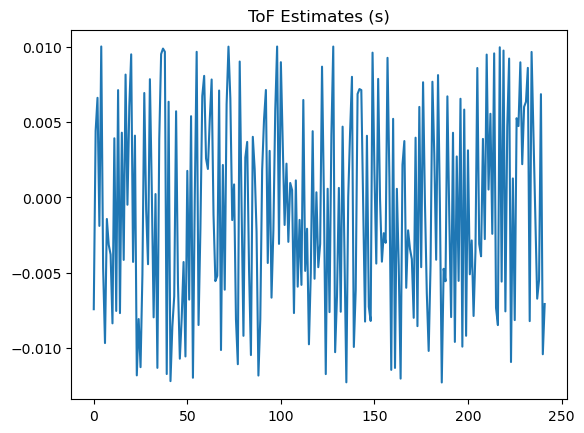

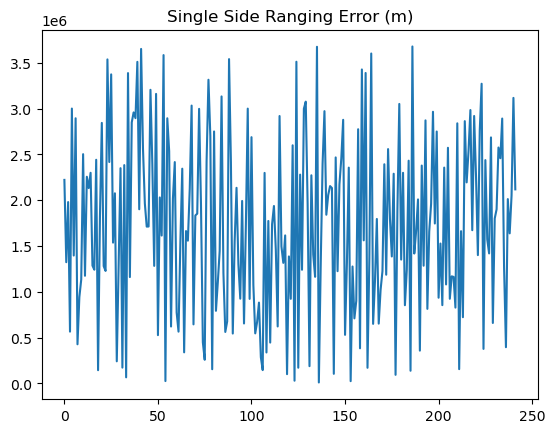

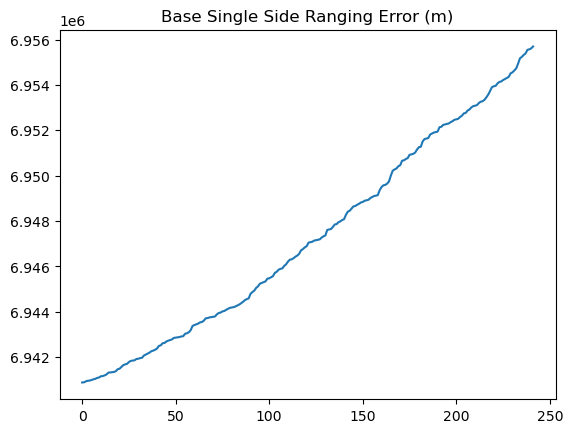

avg_dstwr_err=np.float64(0.027049587162072994)
 std_dstwr_err=np.float64(0.021665392285239574)
avg_ssr_err=np.float64(1739303.3001716926)
 std_ssr_err=np.float64(964193.3141911644)
Min error 11107.013710255678


In [54]:
### Using 3 equations and least squares

def three_eq_ls_no_skew(tof_=GT / SPEED_OF_LIGHT):

    drift_dst_src = [] # drift from destination to source
    skew_dst_src = []
    
    for r in ranges:
        
        poll_src_tx = to_s(r["poll_src_tx"])
        resp_src_rx   = to_s(r["resp_src_rx"])
        final_src_tx  = to_s(r["final_src_tx"])
        poll_dst_rx   = to_s(r["poll_dst_rx"])
        resp_dst_tx   = to_s(r["resp_dst_tx"])
        final_dst_rx  = to_s(r["final_dst_rx"])
        # report_src_rx = to_s(j["report_src_rx"])
        # report_dst_tx = to_s(j["report_dst_tx"])
        
        A = np.array(
                    [[ poll_dst_rx],
                      [resp_dst_tx],
                      [final_dst_rx]]
                    )
        b = np.array([ poll_src_tx + tof_ - poll_dst_rx,
                     resp_src_rx - tof_ - resp_dst_tx,
                     final_src_tx + tof_ - final_dst_rx ])
        
        x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
        drift_dst_src.append(x[0])

    return np.array(drift_dst_src), 0

print(f"Analyzing estimated D, S")

drift_dst_src, _ = three_eq_ls_no_skew()

D_dst_src = np.mean(drift_dst_src)

print("drift mean:", D_dst_src)
print("drift std:", np.std(drift_dst_src))

print(f"Using D, S for SSR")
dstwr_err, ssr_err = evaluate_ssr(D_dst_src, 0)


In [69]:
### Using 2 equations and direct inverse
dstwr_ranges = []

overflow_errors = 0

drift_dst_src = [] # drift from destination to source
skew_dst_src = []

for r in ranges:
    poll_src_tx = to_s(r["poll_src_tx"])
    resp_src_rx   = to_s(r["resp_src_rx"])
    poll_dst_rx   = to_s(r["poll_dst_rx"])
    resp_dst_tx   = to_s(r["resp_dst_tx"])

    # our tof estimate for this system
    tof_ = GT / SPEED_OF_LIGHT

    A = np.array(
                [[ poll_dst_rx, 1],
                  [resp_dst_tx, 1]]
                )
    b = np.array([ poll_src_tx + tof_ - poll_dst_rx,
                 resp_src_rx - tof_ - resp_dst_tx])

    # b = Ax
    x = np.linalg.inv(A) @ b
    drift_dst_src.append(x[0])
    skew_dst_src.append(x[1])

    # print(f"{poll_src_tx=} {poll_dst_rx=}")
    # print(f"{resp_src_rx=} {resp_dst_tx=}")
    
    # print(f"{tof_=}")
    # print(f"{A=}")
    # print(f"{b=}")
    # print(f"{x}")
    # print()

    # print(f"skew = {x[1]}")
    # print(f"{poll_src_tx=}\n {poll_dst_rx=}\n {resp_src_rx=}\n {resp_dst_tx=}\n")

drift_dst_src = np.array(drift_dst_src)
skew_dst_src = np.array(skew_dst_src)

D_dst_src = np.mean(drift_dst_src)
S_dst_src = np.mean(skew_dst_src)

print("drift mean:", D_dst_src)
print("drift stdev:", np.std(drift_dst_src))

print("skew mean:", S_dst_src)
print("skew stdev:", np.std(skew_dst_src))



drift mean: -4.2449524795171006e-07
drift stdev: 1.998942190941367e-07
skew mean: -0.023180661805076306
skew stdev: 1.4742025479819334e-05


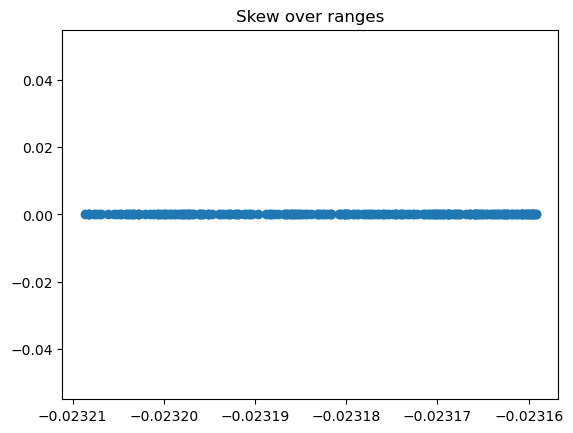

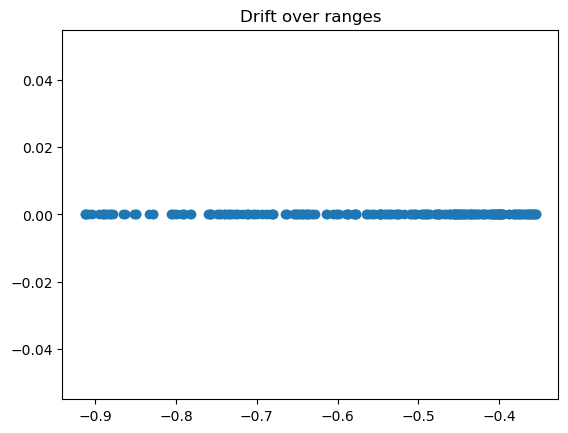

In [80]:

plt.scatter(skew_dst_src,  np.zeros_like(skew_dst_src))
plt.title("Skew over ranges")

plt.show()

plt.scatter(drift_dst_src,  np.zeros_like(drift_dst_src))
plt.title("Drift over ranges")

plt.show()

In [21]:
### Trying to use an optimizer to solve for D and S

from scipy.optimize import minimize

# Initial values (already computed previously)
x0 = np.array([D_dst_src, S_dst_src])
# x0 = np.array([0, 0])

def objective(x):
    D, S = x

    # evaluate SSR using current parameters
    dstwr_err, ssr_err = evaluate_ssr(D, S)

    return ssr_err


result = minimize(
    objective,
    x0,
    method='Nelder-Mead',   # derivative-free, robust starting point
)

# optimized values
D_opt = result.x[0]
S_opt = result.x[1]

print("Optimization success:", result.success)
print("Message:", result.message)

print("Initial D:", D_dst_src)
print("Initial S:", S_dst_src)

print("Optimized D:", D_opt)
print("Optimized S:", S_opt)

# evaluate final performance
dstwr_err, ssr_err = evaluate_ssr(D_opt, S_opt)

print(f"{dstwr_err=}")
print(f"{ssr_err=}")

Optimization success: True
Message: Optimization terminated successfully.
Initial D: -0.5574955988146757
Initial S: nan
Optimized D: -0.44713408733670035
Optimized S: 0.0007448985772830386
dstwr_err=np.float64(0.027049587162072994)
ssr_err=np.float64(6060949.303179926)
